In [2]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    underweight: bool 
    fit : bool 
    overweight : bool
    obese : bool


In [15]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)
    return state 

In [16]:
def diagnosis_with_bmi(state : BMIState) ->BMIState:
    bmi = state['bmi']
    if(bmi<18.5):
        state['underweight'] = True
    elif(bmi>=18.5 and bmi<=25.9):
        state['fit'] = True
    elif(bmi>=25 and bmi<=29.9):
        state['overweight'] = True
    else :
        state['obese'] = True 

    return state


In [17]:
#define your graph
graph = StateGraph(BMIState) 
#add nodes to your graph
graph.add_node('calculate_bmi' , calculate_bmi)
graph.add_node('diagnosis_with_bmi' , diagnosis_with_bmi)
#add edges to your graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi', 'diagnosis_with_bmi')
graph.add_edge('diagnosis_with_bmi',END)

#compile the graph 
workflow = graph.compile()

In [28]:
initial_state = {'weight_kg':50 , 'height_m':1.62}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 50, 'height_m': 1.62, 'bmi': 19.05, 'fit': True}


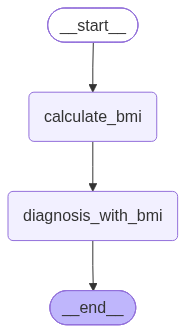

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [4]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    api_key=os.getenv("GEMINI_API_KEY")  
)
parser = StrOutputParser()

In [29]:
class llm_qa(TypedDict):
    question: str
    answer: str
    

In [43]:
def llm_response(state2: llm_qa) -> llm_qa:
    question = state2['question']
    
    prompt = PromptTemplate(
        template=" given this question : {question} give answer" ,
        input_variables=['question']
    )
    final_chain = prompt | llm | parser

    state2['answer'] = final_chain.invoke({'question':question})
    return state2 


In [44]:
graph2= StateGraph(llm_qa)

graph2.add_node('llm_response',llm_response)

graph2.add_edge(START,'llm_response')
graph2.add_edge('llm_response',END)

workflow2 = graph2.compile()




In [46]:
initial_state2 = {'question':'how far is moon from earth'}
final_state2 = workflow2.invoke(initial_state2)
print(final_state2['answer'])

The average distance from the Earth to the Moon is about **238,855 miles** (384,400 kilometers). 

Because the Moon travels in an elliptical (oval-shaped) orbit rather than a perfect circle, the distance changes constantly:
* **Closest point (Perigee):** About 226,000 miles (363,300 km)
* **Farthest point (Apogee):** About 251,000 miles (405,500 km)


In [5]:
class blog(TypedDict):
    topic:str 
    outline:str
    blog:str

In [7]:
def generate_outline(state3:blog)->blog:
    topic = state3['topic']
    prompt = PromptTemplate(
        template='generate outline on topic : {topic}' ,
        input_variables=['topic']
    )
    chain = prompt | llm | parser
    outline = chain.invoke(topic)
    state3['outline'] = outline
    return state3

In [8]:
def generate_blog(state3:blog)->blog:
    outline=state3['outline']
    prompt = PromptTemplate(
        template='generate blog for given outline:{outline}',
        input_variables=['outline']
    )
    chain = prompt | llm | parser 
    final_blog = chain.invoke(outline)
    state3['blog'] = final_blog 
    return state3

In [9]:
graph3 = StateGraph(blog)

graph3.add_node('generate_outline',generate_outline)
graph3.add_node('generate_blog',generate_blog)
graph3.add_edge(START,'generate_outline')
graph3.add_edge('generate_outline','generate_blog')
graph3.add_edge('generate_blog',END)

workflow3=graph3.compile()

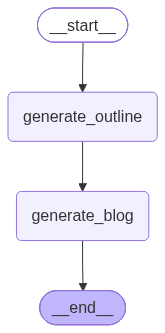

In [10]:
from IPython.display import Image
Image(workflow3.get_graph().draw_mermaid_png())

In [12]:
initial_state3 = {'topic':'AI'}
final_state3 = workflow3.invoke(initial_state3)
print(final_state3['blog'])

# Navigating the Intelligence Age: The Promise and Perils of Artificial Intelligence

Artificial Intelligence (AI) has rapidly shifted from the realm of science fiction into the fabric of our daily lives. Whether it’s diagnosing a rare medical condition, optimizing global supply chains, or curating our evening entertainment, AI is undeniably reshaping our world. 

While AI offers unprecedented advancements in efficiency, medicine, and automation, it simultaneously presents critical ethical, economic, and security challenges that require careful global regulation. Let’s take a comprehensive look at what AI is, how it works, where it is taking us, and what we must do to navigate its future responsibly.

---

## I. Demystifying Artificial Intelligence

At its core, **Artificial Intelligence** refers to the development of computer systems capable of performing tasks that typically require human intelligence—such as learning, reasoning, problem-solving, perception, and language comprehensio